In [ ]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName('COSINE') \
    .config("spark.jars", "/opt/spark/jars/iceberg-spark-runtime-3.5_2.12-1.6.0.jar") \
    .config("spark.sql.extensions", "org.apache.iceberg.spark.extensions.IcebergSparkSessionExtensions") \
    .config("spark.sql.catalog.local", "org.apache.iceberg.spark.SparkCatalog") \
    .config("spark.sql.catalog.spark_catalog.type", "hive") \
    .config("spark.sql.catalog.local.warehouse", "s3a://datalake/iceberg") \
    .getOrCreate()

#Ajuste de log WARN log para ERROR
spark.sparkContext.setLogLevel("ERROR")

In [ ]:
# !pip install sentence-transformers --quiet
# !pip install matplotlib

# <span style="color:#3151B2">Similaridade de Cosseno:</span>

### Forma compacta com produto escalar e norma 
$$
\text{sim}(\mathbf{a}, \mathbf{b}) =
\frac{
    \mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|
}
$$

```python
# As duas expressões para calcular a similaridade do cosseno são matematicamente equivalentes e elas produzem
# exatamente o mesmo resultado. 
# A diferença entre elas está apenas na forma de escrita e interpretação.
```

## <span style="color:#3151B2">Exemplo Prático da forma expandida</span>

### <span style="color:#86CE7E">Forma expandida com somatórios:</span>
 <span style="color:#86CE7E">

$$
\text{sim}(\mathbf{a}, \mathbf{b}) =
\frac{
    \sum_{i=1}^{n} a_i b_i
}{
    \sqrt{\sum_{i=1}^{n} a_i^2} \cdot \sqrt{\sum_{i=1}^{n} b_i^2}
}
$$

</span>

### <span style="color:#BE4936">Dados os vetores:</span>
<span style="color:#BE4936">
$$
\mathbf{a} = [1, 2, 3], \
\mathbf{b} = [4, 5, 6]
$$
</span>

### <span style="color:#9F76DD"> Numerador (produto escalar):</span>

<span style="color:#BE4936">

$$
\begin{align*}
\sum_{i=1}^{3} a_i b_i 
&= a_1 b_1 + a_2 b_2 + a_3 b_3 \\
&= 1 \cdot 4 + 2 \cdot 5 + 3 \cdot 6 \\
&= 4 + 10 + 18 \\
&= 32
\end{align*}
$$

</span>

### <span style="color:#9F76DD"> Denominador (produto das normas):</span>

#### <span style="color:#BE4936">- Norma de $\mathbf{a}$:</span>
<span style="color:#BE4936">
           
\begin{align*}
\|\mathbf{a}\| 
&= \sqrt{a_1^2 + a_2^2 + a_3^2} \\
&= \sqrt{1^2 + 2^2 + 3^2} \\
&= \sqrt{1 + 4 + 9} \\
&= \sqrt{14}
\end{align*}
     
</span>

#### <span style="color:#BE4936">- Norma de $\mathbf{b}$:</span>
<span style="color:#BE4936">
\begin{align*}
\|\mathbf{b}\| 
&= \sqrt{b_1^2 + b_2^2 + b_3^2} \\
&= \sqrt{4^2 + 5^2 + 6^2} \\
&= \sqrt{16 + 25 + 36} \\
&= \sqrt{77}
\end{align*}
</span>


#### <span style="color:#9F76DD"> Similaridade do Cosseno:</span>
<span style="color:#BE4936">

\begin{align*}
\text{sim}(\mathbf{a}, \mathbf{b}) 
&= \frac{\sum a_i b_i}{\|\mathbf{a}\| \cdot \|\mathbf{b}\|} \\
&= \frac{32}{\sqrt{14} \cdot \sqrt{77}} \\
&= \frac{32}{\sqrt{1078}} \\
&\approx \frac{32}{32.8329} \\
&\approx 0.9746
\end{align*}
     
</span>

## <span style="color:#86CE7E">Versão manual em Python e Excel:</span>

In [1]:
import numpy as np

# Vetores de entrada
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Numerador: produto escalar manual (∑ a_i * b_i)
numerador = a[0]*b[0] + a[1]*b[1] + a[2]*b[2]  # 1*4 + 2*5 + 3*6 = 32

# Norma de a: √(∑ a_i^2)
norma_a = np.sqrt(a[0]**2 + a[1]**2 + a[2]**2)  # √(1^2 + 2^2 + 3^2) = √14

# Norma de b: √(∑ b_i^2)
norma_b = np.sqrt(b[0]**2 + b[1]**2 + b[2]**2)  # √(4^2 + 5^2 + 6^2) = √77

# Denominador: produto das normas
denominador = norma_a * norma_b  # √14 * √77 = √1078 ≈ 32.8329

# Similaridade do cosseno: numerador / denominador
similaridade = numerador / denominador  # 32 / 32.8329 ≈ 0.9746

# Resultado final
print(f"Similaridade do cosseno: {similaridade:.4f}")


Similaridade do cosseno: 0.9746


# <span style="color:#3151B2">O que significa esse valor?</span>

#### <span style="color:#86CE7E"> A similaridade do cosseno mede o ângulo entre dois vetores. Ela nos diz o quão alinhados eles estão em direção, independentemente do comprimento (magnitude).</span>

### Interpretando o valo 0.9746:
<span style="color:#86CE7E">

- **Está muito próximo de 1 → isso significa que os vetores "𝑎" e "b" apontam para direções muito parecidas.**

- **Eles não são idênticos, mas estão quase perfeitamente alinhados no espaço.**

- **Caso sejam embeddingns, os textos seriam altamente semelhantes em conteúdo ou tema.**

</span>

# Resumindo tudo

<table style="font-size: 18px;">
  <thead>
    <tr>
      <th>Valor da similaridade</th>
      <th>Significado</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td><b>1</b></td>
      <td>Vetores idênticos na direção (máxima similaridade)</td>
    </tr>
    <tr>
      <td><b>0.9746</b></td>
      <td>Vetores muito parecidos na direção (quase iguais)</td>
    </tr>
    <tr>
      <td><b>0</b></td>
      <td>Vetores ortogonais (sem relação, completamente diferentes)</td>
    </tr>
    <tr>
      <td><b>-1</b></td>
      <td>Vetores exatamente opostos (máxima dissimilaridade)</td>
    </tr>
  </tbody>
</table>


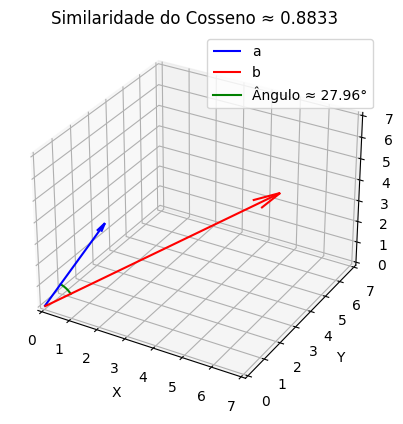

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Vetores de entrada
a = np.array([1, 2, 3])
b = np.array([6, 4, 5])

# Normalização dos vetores para uso no arco
a_unit = a / np.linalg.norm(a)
b_unit = b / np.linalg.norm(b)

# Ângulo entre os vetores
cos_sim = np.dot(a_unit, b_unit)
angle_rad = np.arccos(np.clip(cos_sim, -1.0, 1.0))
angle_deg = np.degrees(angle_rad)

# Gerar pontos para o arco
num_points = 100
t = np.linspace(0, angle_rad, num_points)

# Base ortonormal no plano dos vetores
v1 = a_unit
v2 = b_unit - np.dot(b_unit, v1) * v1
v2 = v2 / np.linalg.norm(v2)

# Pontos do arco
arc = np.array([np.cos(tt) * v1 + np.sin(tt) * v2 for tt in t])

# Plotagem
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Vetores
ax.quiver(0, 0, 0, *a, color='blue', label='a', arrow_length_ratio=0.1)
ax.quiver(0, 0, 0, *b, color='red', label='b', arrow_length_ratio=0.1)

# Arco representando o ângulo
ax.plot(arc[:, 0], arc[:, 1], arc[:, 2], color='green', label=f'Ângulo ≈ {angle_deg:.2f}°')

# Ajuste dos limites
limite = max(np.max(np.abs(a)), np.max(np.abs(b))) + 1
ax.set_xlim([0, limite])
ax.set_ylim([0, limite])
ax.set_zlim([0, limite])

# Rótulos e título
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title(f'Similaridade do Cosseno ≈ {cos_sim:.4f}')

# Legenda
ax.legend()

plt.show()


## Similaridade de Cosseno em Python

In [6]:
# Código com Similaridade de Cosseno e Comentários

from sentence_transformers import SentenceTransformer
import numpy as np
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Inicializa o modelo que converte texto em vetores (embeddings)
model = SentenceTransformer('all-MiniLM-L6-v2')

# Duas frases para comparar
texto1 = "O Brasil é o maior país da América do Sul."
texto2 = "O Brasil é maior que a Argentina"

# Gera os embeddings (vetores de dimensão 384)
embedding1 = model.encode(texto1)  # vetor a = [a₁, a₂, ..., aₙ]
embedding2 = model.encode(texto2)  # vetor b = [b₁, b₂, ..., bₙ]

# ---------- Cálculo manual da Similaridade de Cosseno ----------

# 1. Produto escalar dos vetores → ∑ aᵢ · bᵢ
produto_escalar = np.dot(embedding1, embedding2)

# 2. Norma (magnitude) do vetor a → √∑(aᵢ²)
norma_a = np.linalg.norm(embedding1)

# 3. Norma (magnitude) do vetor b → √∑(bᵢ²)
norma_b = np.linalg.norm(embedding2)

# 4. Similaridade de cosseno → (a · b) / (||a|| * ||b||)
similaridade_cosseno = produto_escalar / (norma_a * norma_b)

# ---------------------------------------------------------------

print(f"Similaridade de Cosseno entre os textos: {similaridade_cosseno:.4f}")


Similaridade de Cosseno entre os textos: 0.6931
